In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from tensorflow import keras
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Definir la ruta base como se especificó
base_path = '/content/drive/MyDrive/Papper_Titulo /'

# Verificar si el directorio existe y listar su contenido para identificar los archivos del conjunto de datos
if os.path.exists(base_path):
    print(f"Contenido de '{base_path}':")
    file_list = os.listdir(base_path)
    for file_name in file_list:
        print(file_name)
else:
    print(f"El directorio '{base_path}' no existe. Por favor verifique la ruta.")

Mounted at /content/drive
Contenido de '/content/drive/MyDrive/Papper_Titulo /':
EEG
03_CNN_EEG_Alcohol_Detection.keras
best_mobilevit_eeg.keras
07_MobileNetV2_EEG.keras
Modelos Hibridos
best_mobilevit2_eeg.keras
05-DeIT_EGG.ipynb
05_DEIT_EEG_Alcohol_Detection.keras
03-CNN_EGG.ipynb
best_mobilenetv2_eeg_finetuned.keras
06_MLPMixer_EEG_Alcohol_Detection.keras
06-MLPMixer_EGG.ipynb
04_BotNet_EEG_Alcohol_Detection.keras
04-BotNet_EGG.ipynb
 07_MOBILENETV2_EGG.ipynb
.ipynb_checkpoints
comparison_results.csv
RESULTADO_MODELOS.ipynb
02-PiT_EGG.ipynb
02_PiT_EEG_Alcohol_Detection.keras
01_ViT_EEG_Alcohol_Detection2.keras
01_ViT_EEG_Alcohol_Detection.keras
01_ViT_EGG.ipynb


In [ ]:
eeg_dir = os.path.join(base_path, 'EEG')

# Listar el contenido del directorio EEG para encontrar los archivos del conjunto de datos
if os.path.exists(eeg_dir):
    print(f"Contenido de '{eeg_dir}':")
    eeg_files = os.listdir(eeg_dir)
    for file_name in eeg_files:
        print(file_name)
else:
    print(f"El directorio '{eeg_dir}' no existe.")

Contenido de '/content/drive/MyDrive/Papper_Titulo /EEG':
Alc
Con


In [ ]:
alc_dir = os.path.join(eeg_dir, 'Alc')
con_dir = os.path.join(eeg_dir, 'Con')

# Verificar contenido del directorio Alc
if os.path.exists(alc_dir):
    print(f"Contenido de '{alc_dir}' (primeros 5 archivos):")
    alc_files = os.listdir(alc_dir)
    for file_name in alc_files[:5]:
        print(file_name)
else:
    print(f"'{alc_dir}' no existe.")

# Verificar contenido del directorio Con
if os.path.exists(con_dir):
    print(f"Contenido de '{con_dir}' (primeros 5 archivos):")
    con_files = os.listdir(con_dir)
    for file_name in con_files[:5]:
        print(file_name)
else:
    print(f"'{con_dir}' no existe.")

Contenido de '/content/drive/MyDrive/Papper_Titulo /EEG/Alc' (primeros 5 archivos):
23_co2a0000364_4.jpg
63_co2a0000371_30.jpg
43_co2a0000372_0.jpg
34_co2a0000375_32.jpg
20_co2a0000368_62.jpg
Contenido de '/content/drive/MyDrive/Papper_Titulo /EEG/Con' (primeros 5 archivos):
107_co2c0000337_21.jpg
71_co2c0000342_24.jpg
61_co2c0000345_18.jpg
60_co2c0000339_5.jpg
85_co2c0000337_62.jpg


**Razonamiento**:
Se carga las imágenes de los directorios 'Alc' y 'Con', se redimenciona a 224x224 (un tamaño de entrada estándar para modelos preentrenados como ViT y MobileNet), y se normaliza los valores de los píxeles y divide el conjunto de datos en conjuntos de entrenamiento y prueba según se solicite



In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import load_img, img_to_array

# Definir tamaño de imagen (224x224 es estándar para muchos modelos pre-entrenados)
IMG_SIZE = (224, 224)

X = []
y = []

# Función para cargar imágenes de un directorio
def load_images_from_dir(directory, label, label_name):
    count = 0
    if os.path.exists(directory):
        print(f"Cargando imágenes de {label_name} desde '{directory}'...")
        files = os.listdir(directory)
        for filename in files:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(directory, filename)
                try:
                    # Cargar y redimensionar imagen
                    img = load_img(img_path, target_size=IMG_SIZE)
                    img_arr = img_to_array(img)
                    X.append(img_arr)
                    y.append(label)
                    count += 1
                except Exception as e:
                    print(f"Error cargando {filename}: {e}")
        print(f"Cargadas {count} imágenes para la clase {label_name}.")
    else:
        print(f"El directorio '{directory}' no existe.")

# Cargar datos de Alcohol (1) y Control (0)
# Usando variables 'alc_dir' y 'con_dir' de celdas anteriores
load_images_from_dir(alc_dir, 1, "Alcohol")
load_images_from_dir(con_dir, 0, "Control")

# Convertir a arrays de numpy
X = np.array(X)
y = np.array(y)

# Normalizar valores de píxeles a [0, 1]
X = X / 255.0

# Dividir en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nCarga y Preprocesamiento de Datos Completado.")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")

Cargando imágenes de Alcohol desde '/content/drive/MyDrive/Papper_Titulo /EEG/Alc'...
Cargadas 468 imágenes para la clase Alcohol.
Cargando imágenes de Control desde '/content/drive/MyDrive/Papper_Titulo /EEG/Con'...
Cargadas 456 imágenes para la clase Control.

Carga y Preprocesamiento de Datos Completado.
Forma de X_train: (739, 224, 224, 3)
Forma de y_train: (739,)
Forma de X_test: (185, 224, 224, 3)
Forma de y_test: (185,)


## Cargar modelos preentrenados

### Subtarea:
Cargar los modelos Keras preentrenados especificados (ViT, PiT, CNN, BotNet, MLPMixer, MobileNetV2) desde los archivos de Google Drive identificados.


In [ ]:
import tensorflow as tf
from tensorflow import keras
import os
import inspect

# Manejar diferentes versiones de Keras para el decorador
try:
    # Keras más nuevo (v3+ o TF reciente)
    register_serializable = keras.saving.register_keras_serializable
except AttributeError:
    # Keras/TF más antiguo
    register_serializable = keras.utils.register_keras_serializable

# 1. Definir función robusta de inyección de configuración
def inject_robust_from_config(cls, defaults=None):
    if defaults is None:
        defaults = {}

    def from_config(cls, config):
        # Ayudante para inyectar recursivamente valores predeterminados en configuraciones anidadas
        def recursive_inject(item):
            if isinstance(item, dict):
                # Verificar estructura de objeto Keras serializado
                if 'class_name' in item and 'config' in item:
                    inner_config = item['config']
                    # Inyectar valores predeterminados si faltan
                    if isinstance(inner_config, dict):
                        for k, v in defaults.items():
                            if k not in inner_config:
                                inner_config[k] = v
                        # Recursión en la configuración interna
                        item['config'] = recursive_inject(inner_config)

                # Recursión en todos los valores
                for k, v in item.items():
                    item[k] = recursive_inject(v)
            elif isinstance(item, list):
                return [recursive_inject(i) for i in item]
            return item

        # Preparar copia de configuración
        config_copy = config.copy()

        # Inyectar valores predeterminados en la configuración de nivel superior
        for k, v in defaults.items():
            if k not in config_copy:
                config_copy[k] = v

        # Procesar estructuras anidadas
        config_copy = recursive_inject(config_copy)

        # Instanciar
        return cls(**config_copy)

    # Adjuntar método
    cls.from_config = classmethod(from_config)

# 2. Definir Clases Personalizadas con init flexible
@register_serializable()
class ViTClassfier(keras.Model):
    def __init__(self, **kwargs):
        # Filtrar kwargs para evitar pasar argumentos inválidos a super
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable']}
        super().__init__(**super_kwargs)
        self._config = kwargs
    def get_config(self):
        return self._config
    def call(self, inputs):
        return inputs

@register_serializable()
class PiTClassifier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable']}
        super().__init__(**super_kwargs)
        self._config = kwargs
    def get_config(self):
        return self._config
    def call(self, inputs):
        return inputs

@register_serializable()
class CNNClassifier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable']}
        super().__init__(**super_kwargs)
        self._config = kwargs
    def get_config(self):
        return self._config
    def call(self, inputs):
        return inputs

@register_serializable()
class BotNetClassifier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable']}
        super().__init__(**super_kwargs)
        self._config = kwargs
    def get_config(self):
        return self._config
    def call(self, inputs):
        return inputs

@register_serializable()
class MLPMixer(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable']}
        super().__init__(**super_kwargs)
        self._config = kwargs
    def get_config(self):
        return self._config
    def call(self, inputs):
        return inputs

@register_serializable()
class BalancedSparseCategoricalAccuracy(keras.metrics.Metric):
    def __init__(self, name='balanced_sparse_categorical_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        pass
    def result(self):
        return 0.0
    def reset_state(self):
        pass

# 3. Aplicar Parche
defaults = {'input_shape': (224, 224, 3), 'n_classes': 2}
for cls in [ViTClassfier, PiTClassifier, CNNClassifier, BotNetClassifier, MLPMixer]:
    inject_robust_from_config(cls, defaults)

# 4. Cargar Modelos
model_files = {
    'ViT': '01_ViT_EEG_Alcohol_Detection.keras',
    'PiT': '02_PiT_EEG_Alcohol_Detection.keras',
    'CNN': '03_CNN_EEG_Alcohol_Detection.keras',
    'BotNet': '04_BotNet_EEG_Alcohol_Detection.keras',
    'MLPMixer': '06_MLPMixer_EEG_Alcohol_Detection.keras',
    'MobileNetV2': '07_MobileNetV2_EEG.keras'
}

custom_objects = {
    'ViTClassfier': ViTClassfier,
    'PiTClassifier': PiTClassifier,
    'CNNClassifier': CNNClassifier,
    'BotNetClassifier': BotNetClassifier,
    'MLPMixer': MLPMixer,
    'BalancedSparseCategoricalAccuracy': BalancedSparseCategoricalAccuracy
}

# Reutilizar base_path del contexto anterior si está disponible, sino definirlo
if 'base_path' not in locals():
    base_path = '/content/drive/MyDrive/Papper_Titulo /'

models = {}
print("Recargando modelos con manejo robusto de configuración...")

for name, filename in model_files.items():
    path = os.path.join(base_path, filename)
    if os.path.exists(path):
        try:
            models[name] = keras.models.load_model(path, custom_objects=custom_objects)
            print(f"Cargado exitosamente {name}")
        except Exception as e:
            print(f"Fallo al cargar {name}: {e}")
    else:
        print(f"Archivo no encontrado: {path}")

print("\nModelos Cargados:", list(models.keys()))

Recargando modelos con manejo robusto de configuración...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cargado exitosamente ViT


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 210 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cargado exitosamente PiT


...

Cargado exitosamente CNN


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 262 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cargado exitosamente BotNet


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 206 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cargado exitosamente MLPMixer
Cargado exitosamente MobileNetV2

Modelos Cargados: ['ViT', 'PiT', 'CNN', 'BotNet', 'MLPMixer', 'MobileNetV2']


In [ ]:
import json
import os

base_path = '/content/drive/MyDrive/Papper_Titulo /'
notebook_files = {
    'ViTClassfier': '01_ViT_EGG.ipynb',
    'PiTClassifier': '02-PiT_EGG.ipynb',
    'CNNClassifier': '03-CNN_EGG.ipynb',
    'BotNetClassifier': '04-BotNet_EGG.ipynb',
    'MLPMixer': '06-MLPMixer_EGG.ipynb'
}

print("Extrayendo definiciones de clases de los notebooks...")

for class_name, nb_file in notebook_files.items():
    nb_path = os.path.join(base_path, nb_file)
    print(f"\n--- Escaneando {nb_file} para buscar {class_name} ---")
    if os.path.exists(nb_path):
        try:
            with open(nb_path, 'r', encoding='utf-8') as f:
                nb = json.load(f)

            found = False
            for cell in nb['cells']:
                if cell['cell_type'] == 'code':
                    source_lines = cell['source']
                    source_text = ''.join(source_lines)
                    if f"class {class_name}" in source_text:
                        print(f"Definición encontrada para {class_name}:")
                        print(source_text)
                        print("-" * 20)
                        found = True
                        # Podríamos necesitar importaciones relacionadas o funciones auxiliares de celdas anteriores
                        # Pero usualmente la celda de la clase es autocontenida o podemos inferir las importaciones.
                        # Por ahora, solo obtendremos la clase.
            if not found:
                print(f"Clase {class_name} no encontrada en {nb_file}.")
        except Exception as e:
            print(f"Error leyendo {nb_file}: {e}")
    else:
        print(f"Archivo no encontrado: {nb_path}")

Extrayendo definiciones de clases de los notebooks...

--- Escaneando 01_ViT_EGG.ipynb para buscar ViTClassfier ---
Definición encontrada para ViTClassfier:
#02
import tensorflow as tf

class Patches(tf.keras.layers.Layer):
  # Divide una imagen en parches de tamaño dado y los devuelve.
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


class PatchEncoder(tf.keras.layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__i

**Razonamiento**:
Redefinir la función `inject_robust_from_config` para excluir específicamente los objetos que no son de capa, como `DTypePolicy`, de recibir argumentos predeterminados para evitar errores de inicialización. A continuación, se redefine las clases de modelo personalizados (`ViTClassfier`, `PiTClassifier`, `CNNClassifier`, `BotNetClassifier`, `MLPMixer`) y las clases auxiliares, asegurándome de que `MixerBlock` use los nombres de atributo correctos (`layer_norm1`, `layer_norm2`) para que coincidan con los pesos guardados. Finalmente, recargaré todos los modelos con estas definiciones corregidas y verificaré los resultados.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import os

# Manejar diferentes versiones de Keras para el decorador
try:
    register_serializable = keras.saving.register_keras_serializable
except AttributeError:
    register_serializable = keras.utils.register_keras_serializable

# 1. Definir función robusta de inyección de configuración con exclusiones explícitas
def inject_robust_from_config(cls, defaults=None):
    if defaults is None:
        defaults = {}

    def from_config(cls, config):
        # Lista de exclusión para prevenir errores de 'unexpected keyword argument'
        EXCLUDE_FROM_INJECTION = [
            'DTypePolicy', 'Adam', 'SparseCategoricalCrossentropy',
            'BalancedSparseCategoricalAccuracy', 'l2', 'GlorotUniform',
            'Zeros', 'One', 'Constant'
        ]

        def recursive_inject(item):
            if isinstance(item, dict):
                if 'class_name' in item and 'config' in item:
                    # Verificar si este objeto debe ser omitido
                    if item['class_name'] not in EXCLUDE_FROM_INJECTION:
                        inner_config = item['config']
                        if isinstance(inner_config, dict):
                            for k, v in defaults.items():
                                if k not in inner_config:
                                    inner_config[k] = v
                            item['config'] = recursive_inject(inner_config)
                # Recursión en valores
                for k, v in item.items():
                    item[k] = recursive_inject(v)
            elif isinstance(item, list):
                return [recursive_inject(i) for i in item]
            return item

        config_copy = config.copy()
        # Inyectar valores predeterminados de nivel superior
        for k, v in defaults.items():
            if k not in config_copy:
                config_copy[k] = v

        # Inyectar valores predeterminados anidados
        config_copy = recursive_inject(config_copy)

        return cls(**config_copy)

    cls.from_config = classmethod(from_config)

# --- Clases Auxiliares ---

class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID")
        patch_dims = patches.shape[-1]
        if images.shape[1] is not None and images.shape[2] is not None:
            seq_len = (images.shape[1] // self.patch_size) * (images.shape[2] // self.patch_size)
            patches = tf.reshape(patches, [batch_size, seq_len, patch_dims])
        else:
            patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches
    def get_config(self):
        config = super().get_config()
        config.update({'patch_size': self.patch_size})
        return config

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)
    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch)
        pos_emb = self.position_embedding(positions)
        pos_emb = tf.expand_dims(pos_emb, axis=0)
        return encoded + pos_emb
    def get_config(self):
        config = super().get_config()
        config.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return config

def TransformerBlock(x, heads, key_dim, units, dropout):
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    att = layers.MultiHeadAttention(num_heads=heads, key_dim=key_dim, dropout=dropout)(x1, x1)
    x2 = layers.Add()([x, att])
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(units, activation=tf.nn.gelu)(x3)
    x3 = layers.Dropout(dropout)(x3)
    x3 = layers.Dense(x.shape[-1])(x3)
    x3 = layers.Dropout(dropout)(x3)
    return layers.Add()([x2, x3])

class MHSA(layers.Layer):
    def __init__(self, num_heads=4, key_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
    def call(self, x):
        shape = tf.shape(x)
        B, H, W, C = shape[0], shape[1], shape[2], shape[3]
        x_flat = tf.reshape(x, (B, H * W, C))
        out_flat = self.mha(x_flat, x_flat)
        return tf.reshape(out_flat, (B, H, W, C))
    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})
        return config

def bottleneck_block(x, filters, stride=1, use_attention=False, heads=4):
    shortcut = x
    in_filters = x.shape[-1]
    out_filters = filters * 4
    if stride != 1 or in_filters != out_filters:
        shortcut = layers.Conv2D(out_filters, kernel_size=1, strides=stride, padding="same")(x)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Conv2D(filters, kernel_size=1, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if use_attention:
        if stride > 1: x = layers.AveragePooling2D(pool_size=(2,2), strides=(2,2), padding="same")(x)
        x = MHSA(num_heads=heads, key_dim=filters // heads)(x)
        x = layers.LayerNormalization(epsilon=1e-6)(x)
    else:
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    x = layers.Conv2D(out_filters, kernel_size=1, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    return layers.Activation("relu")(x)

class MLPBlock(layers.Layer):
    def __init__(self, hidden_dim, activation=tf.nn.gelu, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.activation = activation
    def build(self, input_shape):
        self.dense1 = layers.Dense(self.hidden_dim)
        self.dense2 = layers.Dense(input_shape[-1])
        super().build(input_shape)
    def call(self, x):
        y = self.dense1(x)
        y = self.activation(y)
        return self.dense2(y)
    def get_config(self):
        config = super().get_config()
        config.update({'hidden_dim': self.hidden_dim})
        return config

class MixerBlock(layers.Layer):
    def __init__(self, tokens_mlp_dim, channels_mlp_dim, **kwargs):
        super().__init__(**kwargs)
        self.tokens_mlp_dim = tokens_mlp_dim
        self.channels_mlp_dim = channels_mlp_dim
    def build(self, input_shape):
        # Nombres correctos para coincidir con pesos guardados (layer_norm1, layer_norm2)
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.token_mixing = MLPBlock(self.tokens_mlp_dim)
        self.channel_mixing = MLPBlock(self.channels_mlp_dim)
        super().build(input_shape)
    def call(self, x):
        y = self.layer_norm1(x)
        y = tf.transpose(y, [0, 2, 1])
        y = self.token_mixing(y)
        y = tf.transpose(y, [0, 2, 1])
        x = layers.Add()([x, y])
        y = self.layer_norm2(x)
        y = self.channel_mixing(y)
        return layers.Add()([x, y])
    def get_config(self):
        config = super().get_config()
        config.update({'tokens_mlp_dim': self.tokens_mlp_dim, 'channels_mlp_dim': self.channels_mlp_dim})
        return config

class PoolingLayer(layers.Layer):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.output_dim_val = output_dim
        self.pool = layers.DepthwiseConv2D(kernel_size=3, strides=2, padding='same')
        self.conv = layers.Conv2D(output_dim, kernel_size=1)
    def call(self, inputs):
        shape = tf.shape(inputs)
        B, N, C = shape[0], shape[1], shape[2]
        H = tf.cast(tf.sqrt(tf.cast(N, tf.float32)), tf.int32)
        x = tf.reshape(inputs, (B, H, H, C))
        x = self.pool(x)
        x = self.conv(x)
        return tf.reshape(x, (B, -1, tf.shape(x)[-1]))
    def get_config(self):
        config = super().get_config()
        config.update({'output_dim': self.output_dim_val})
        return config

# --- Clases Principales de Modelos (Arquitecturas Completas) ---

@register_serializable()
class ViTClassfier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable', 'dtype']}
        super().__init__(**super_kwargs)
        self.input_shape_val = kwargs.get('input_shape', (224, 224, 3))
        self.n_classes_val = kwargs.get('n_classes', 2)
        self.patch_size = kwargs.get('patch_size', 8)
        self.embedding_dim = kwargs.get('embedding_dim', 64)
        self._construct_model()

    def _construct_model(self):
        inputs = layers.Input(shape=self.input_shape_val)
        num_patches = (self.input_shape_val[0] // self.patch_size) ** 2
        patches = Patches(self.patch_size)(inputs)
        encoded = PatchEncoder(num_patches, self.embedding_dim)(patches)

        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded)
        att = layers.MultiHeadAttention(num_heads=3, key_dim=self.embedding_dim, dropout=0.1)(x1, x1)
        x2 = layers.Add()([att, encoded])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = layers.Dense(200, activation=tf.nn.gelu)(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(self.embedding_dim)(x3)
        x3 = layers.Dropout(0.1)(x3)
        encoded = layers.Add()([x3, x2])

        features = layers.LayerNormalization(epsilon=1e-6)(encoded)
        features = layers.Flatten()(features)
        features = layers.Dropout(0.5)(features)
        features = layers.Dense(2048, activation=tf.nn.gelu)(features)
        features = layers.Dropout(0.1)(features)
        features = layers.Dense(1024, activation=tf.nn.gelu)(features)
        features = layers.Dropout(0.1)(features)
        outputs = layers.Dense(self.n_classes_val)(features)
        self._model = keras.models.Model(inputs=inputs, outputs=outputs)
    def call(self, x): return self._model(x)
    def get_config(self): return {'input_shape': self.input_shape_val, 'n_classes': self.n_classes_val}

@register_serializable()
class PiTClassifier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable', 'dtype']}
        super().__init__(**super_kwargs)
        self.input_tensor_shape = kwargs.get('input_shape', (224, 224, 3))
        self.n_classes = kwargs.get('n_classes', 2)
        self._construct_model()
    def _construct_model(self):
        patch_size, base_dims, heads, transformers, dropout, mlp_ratio = 16, [32, 64, 128], [2, 4, 8], [2, 2, 2], 0.1, 4
        inputs = layers.Input(shape=self.input_tensor_shape)
        x = layers.Conv2D(filters=base_dims[0], kernel_size=patch_size, strides=patch_size, padding='valid')(inputs)
        h1, w1 = x.shape[1], x.shape[2]
        seq_len1 = h1 * w1
        x = layers.Reshape((seq_len1, base_dims[0]))(x)
        pos_emb1 = layers.Embedding(input_dim=seq_len1, output_dim=base_dims[0])(tf.range(seq_len1))
        x = x + pos_emb1
        for _ in range(transformers[0]):
            x = TransformerBlock(x, heads[0], base_dims[0] // heads[0], base_dims[0] * mlp_ratio, dropout)
        x = layers.Reshape((h1, w1, base_dims[0]))(x)
        x = layers.Conv2D(base_dims[1], kernel_size=3, strides=2, padding='same')(x)
        h2, w2 = x.shape[1], x.shape[2]
        seq_len2 = h2 * w2
        x = layers.Reshape((seq_len2, base_dims[1]))(x)
        pos_emb2 = layers.Embedding(input_dim=seq_len2, output_dim=base_dims[1])(tf.range(seq_len2))
        x = x + pos_emb2
        for _ in range(transformers[1]):
            x = TransformerBlock(x, heads[1], base_dims[1] // heads[1], base_dims[1] * mlp_ratio, dropout)
        x = layers.Reshape((h2, w2, base_dims[1]))(x)
        x = layers.Conv2D(base_dims[2], kernel_size=3, strides=2, padding='same')(x)
        h3, w3 = x.shape[1], x.shape[2]
        seq_len3 = h3 * w3
        x = layers.Reshape((seq_len3, base_dims[2]))(x)
        pos_emb3 = layers.Embedding(input_dim=seq_len3, output_dim=base_dims[2])(tf.range(seq_len3))
        x = x + pos_emb3
        for _ in range(transformers[2]):
            x = TransformerBlock(x, heads[2], base_dims[2] // heads[2], base_dims[2] * mlp_ratio, dropout)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(self.n_classes)(x)
        self._model = keras.models.Model(inputs=inputs, outputs=outputs)
    def call(self, x): return self._model(x)
    def get_config(self): return {'input_shape': self.input_tensor_shape, 'n_classes': self.n_classes}

@register_serializable()
class CNNClassifier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable', 'dtype']}
        super().__init__(**super_kwargs)
        self.input_tensor_shape = kwargs.get('input_shape', (224, 224, 3))
        self.n_classes = kwargs.get('n_classes', 2)
        self._construct_model()
    def _construct_model(self):
        inputs = layers.Input(shape=self.input_tensor_shape)
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Flatten()(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(self.n_classes)(x)
        self._model = keras.models.Model(inputs=inputs, outputs=outputs)
    def call(self, x): return self._model(x)
    def get_config(self): return {'input_shape': self.input_tensor_shape, 'n_classes': self.n_classes}

@register_serializable()
class BotNetClassifier(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable', 'dtype']}
        super().__init__(**super_kwargs)
        self.input_tensor_shape = kwargs.get('input_shape', (224, 224, 3))
        self.n_classes = kwargs.get('n_classes', 2)
        self._construct_model()
    def _construct_model(self):
        inputs = layers.Input(shape=self.input_tensor_shape)
        x = layers.Conv2D(64, 7, strides=2, padding="same")(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)
        x = bottleneck_block(x, 64, stride=1)
        x = bottleneck_block(x, 64, stride=1)
        x = bottleneck_block(x, 128, stride=2)
        x = bottleneck_block(x, 128, stride=1)
        x = bottleneck_block(x, 256, stride=2)
        x = bottleneck_block(x, 256, stride=1)
        x = bottleneck_block(x, 512, stride=2, use_attention=True)
        x = bottleneck_block(x, 512, stride=1, use_attention=True)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(self.n_classes)(x)
        self._model = keras.models.Model(inputs=inputs, outputs=outputs)
    def call(self, x): return self._model(x)
    def get_config(self): return {'input_shape': self.input_tensor_shape, 'n_classes': self.n_classes}

@register_serializable()
class MLPMixer(keras.Model):
    def __init__(self, **kwargs):
        super_kwargs = {k: v for k, v in kwargs.items() if k in ['name', 'trainable', 'dtype']}
        super().__init__(**super_kwargs)
        self.input_tensor_shape = kwargs.get('input_shape', (224, 224, 3))
        self.n_classes = kwargs.get('n_classes', 2)
        self.patch_size = kwargs.get('patch_size', 16)
        self.embedding_dim = kwargs.get('embedding_dim', 256)
        self.num_blocks = kwargs.get('num_blocks', 8)
        self.tokens_mlp_dim = kwargs.get('tokens_mlp_dim', 128)
        self.channels_mlp_dim = kwargs.get('channels_mlp_dim', 1024)
        self._construct_model()
    def _construct_model(self):
        inputs = layers.Input(shape=self.input_tensor_shape)
        patches = Patches(self.patch_size)(inputs)
        x = layers.Dense(self.embedding_dim)(patches)
        for _ in range(self.num_blocks):
            x = MixerBlock(self.tokens_mlp_dim, self.channels_mlp_dim)(x)
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.GlobalAveragePooling1D()(x)
        outputs = layers.Dense(self.n_classes)(x)
        self._model = keras.models.Model(inputs=inputs, outputs=outputs)
    def call(self, x): return self._model(x)
    def get_config(self):
        return {
            'input_shape': self.input_tensor_shape, 'n_classes': self.n_classes,
            'patch_size': self.patch_size, 'embedding_dim': self.embedding_dim,
            'num_blocks': self.num_blocks, 'tokens_mlp_dim': self.tokens_mlp_dim,
            'channels_mlp_dim': self.channels_mlp_dim
        }

@register_serializable()
class BalancedSparseCategoricalAccuracy(keras.metrics.Metric):
    def __init__(self, name='balanced_sparse_categorical_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        pass
    def result(self): return 0.0
    def reset_state(self): pass

# --- Aplicar Inyección ---
defaults = {'input_shape': (224, 224, 3), 'n_classes': 2}
for cls in [ViTClassfier, PiTClassifier, CNNClassifier, BotNetClassifier, MLPMixer]:
    inject_robust_from_config(cls, defaults)

# --- Cargar Modelos ---
model_files = {
    'ViT': '01_ViT_EEG_Alcohol_Detection.keras',
    'PiT': '02_PiT_EEG_Alcohol_Detection.keras',
    'CNN': '03_CNN_EEG_Alcohol_Detection.keras',
    'BotNet': '04_BotNet_EEG_Alcohol_Detection.keras',
    'MLPMixer': '06_MLPMixer_EEG_Alcohol_Detection.keras',
    'MobileNetV2': '07_MobileNetV2_EEG.keras'
}

custom_objects = {
    'ViTClassfier': ViTClassfier, 'PiTClassifier': PiTClassifier, 'CNNClassifier': CNNClassifier,
    'BotNetClassifier': BotNetClassifier, 'MLPMixer': MLPMixer,
    'BalancedSparseCategoricalAccuracy': BalancedSparseCategoricalAccuracy,
    'Patches': Patches, 'PatchEncoder': PatchEncoder, 'PoolingLayer': PoolingLayer, 'MHSA': MHSA,
    'MLPBlock': MLPBlock, 'MixerBlock': MixerBlock
}

if 'base_path' not in locals():
    base_path = '/content/drive/MyDrive/Papper_Titulo /'

loaded_models = {}
print("Recargando modelos con arquitecturas completas...")
for name, filename in model_files.items():
    path = os.path.join(base_path, filename)
    if os.path.exists(path):
        try:
            loaded_models[name] = keras.models.load_model(path, custom_objects=custom_objects)
            print(f"Cargado exitosamente {name}")
        except Exception as e:
            print(f"Fallo al cargar {name}: {e}")
    else:
        print(f"Archivo no encontrado: {path}")

print("\nModelos Finales Cargados:", list(loaded_models.keys()))

Recargando modelos con arquitecturas completas...
Cargado exitosamente ViT
Cargado exitosamente PiT
Cargado exitosamente CNN
Cargado exitosamente BotNet
Cargado exitosamente MLPMixer
Cargado exitosamente MobileNetV2

Modelos Finales Cargados: ['ViT', 'PiT', 'CNN', 'BotNet', 'MLPMixer', 'MobileNetV2']


In [ ]:
import numpy as np
from tensorflow import keras

# 1. Asegurar float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# 2. Inicializar diccionario
extracted_features = {}

# 3. Iterar modelos (Silencioso)
if 'loaded_models' in locals():
    for name, model in loaded_models.items():
        try:
            # 4. Identificar modelo funcional de Keras
            if hasattr(model, '_model'):
                functional_model = model._model
            else:
                functional_model = model

            # 5. Crear extractor de características (Penúltima capa)
            if hasattr(functional_model, 'layers') and len(functional_model.layers) >= 2:
                penultimate_layer = functional_model.layers[-2]
                # Manejar casos donde la entrada podría estar desconectada o ser compleja
                extractor = keras.Model(inputs=functional_model.input, outputs=penultimate_layer.output)

                # 6. Predecir
                # verbose=0 para evitar saturar la salida
                train_feats = extractor.predict(X_train, batch_size=64, verbose=0)
                test_feats = extractor.predict(X_test, batch_size=64, verbose=0)

                # 7. Verificar dimensiones y Aplanar/GAP
                if len(train_feats.shape) > 2:
                    if len(train_feats.shape) == 4:
                        # Tensor 4D (Lote, Altura, Ancho, Canales) -> GAP
                        train_feats = np.mean(train_feats, axis=(1, 2))
                        test_feats = np.mean(test_feats, axis=(1, 2))
                    elif len(train_feats.shape) == 3:
                        # Tensor 3D (Lote, Secuencia, Características) -> GAP
                        train_feats = np.mean(train_feats, axis=1)
                        test_feats = np.mean(test_feats, axis=1)

                # 8. Almacenar resultados
                extracted_features[name] = {
                    'train': train_feats,
                    'test': test_feats
                }

            else:
                print(f"  Error: {name} no tiene suficientes capas para extracción.")

        except Exception as e:
            print(f"  Error extrayendo características para {name}: {e}")
else:
    print("Error: diccionario 'loaded_models' no encontrado.")

# 9. Mostrar solo Resultados Finales
print("\n=== Resultados Finales de Extracción de Características ===")
if extracted_features:
    for name, feats in extracted_features.items():
        print(f"Modelo: {name:<15} | Train Shape: {str(feats['train'].shape):<15} | Test Shape: {str(feats['test'].shape):<15}")
else:
    print("No se extrajeron características.")


=== Resultados Finales de Extracción de Características ===
Modelo: ViT             | Train Shape: (739, 1024)     | Test Shape: (185, 1024)    
Modelo: PiT             | Train Shape: (739, 128)      | Test Shape: (185, 128)     
Modelo: CNN             | Train Shape: (739, 512)      | Test Shape: (185, 512)     
Modelo: BotNet          | Train Shape: (739, 2048)     | Test Shape: (185, 2048)    
Modelo: MLPMixer        | Train Shape: (739, 256)      | Test Shape: (185, 256)     
Modelo: MobileNetV2     | Train Shape: (739, 128)      | Test Shape: (185, 128)     



## Entrenar clasificadores híbridos

### Subtarea:
Entrenar clasificadores SVM, Random Forest y k-NN utilizando las características extraídas de los 6 modelos.



**Razonamiento**:
Entrena los clasificadores híbridos (SVM, Random Forest, k-NN) para cada uno de los 6 modelos de aprendizaje profundo utilizando las características extraídas y almacenaré las predicciones para su evaluación.


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

# Inicializar diccionarios
hybrid_predictions = {}
trained_models = {}

# Validación cruzada: 5 splits es estándar y robusto
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if 'extracted_features' in locals() and extracted_features:
    print("=== Entrenando Clasificadores Híbridos ===")

    for dl_model_name, feats in extracted_features.items():
        print(f"\nProcesando {dl_model_name}...")
        X_train_feat = feats['train']
        X_test_feat = feats['test']
        hybrid_predictions[dl_model_name] = {}
        trained_models[dl_model_name] = {}

        # 1. SVM: Usamos PCA al 95% para agilizar
        pipe_svm = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.95)),
            ('svm', SVC(probability=True, random_state=42, class_weight='balanced'))
        ])
        # Grid simplificado con valores efectivos
        param_grid_svm = {
            'svm__C': [0.1, 1, 10],
            'svm__kernel': ['linear', 'rbf'],
            'svm__gamma': ['scale', 0.01]
        }
        grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
        grid_svm.fit(X_train_feat, y_train)

        hybrid_predictions[dl_model_name]['SVM'] = grid_svm.predict(X_test_feat)
        trained_models[dl_model_name]['SVM'] = grid_svm.best_estimator_
        print(f"  SVM Best: {grid_svm.best_params_} | CV Score: {grid_svm.best_score_:.4f}")

        # 2. Random Forest: Robusto y rápido
        pipe_rf = Pipeline([
            ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
        ])
        param_grid_rf = {
            'rf__n_estimators': [100, 200, 300],
            'rf__max_depth': [None, 20],
            'rf__min_samples_leaf': [1, 2]
        }
        grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
        grid_rf.fit(X_train_feat, y_train)

        hybrid_predictions[dl_model_name]['Random Forest'] = grid_rf.predict(X_test_feat)
        trained_models[dl_model_name]['Random Forest'] = grid_rf.best_estimator_
        print(f"  RF Best: {grid_rf.best_params_} | CV Score: {grid_rf.best_score_:.4f}")

        # 3. k-NN: Distancia coseno suele ir mejor en embeddings
        pipe_knn = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.95)),
            ('knn', KNeighborsClassifier())
        ])
        param_grid_knn = {
            'knn__n_neighbors': [5, 15, 25],
            'knn__weights': ['distance'],
            'knn__metric': ['cosine', 'euclidean']
        }
        grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
        grid_knn.fit(X_train_feat, y_train)

        hybrid_predictions[dl_model_name]['k-NN'] = grid_knn.predict(X_test_feat)
        trained_models[dl_model_name]['k-NN'] = grid_knn.best_estimator_
        print(f"  k-NN Best: {grid_knn.best_params_} | CV Score: {grid_knn.best_score_:.4f}")

else:
    print("Error: No se encontraron las características extraídas.")

=== Entrenando Clasificadores Híbridos ===

Procesando ViT...
  SVM Best: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'} | CV Score: 0.9756
  RF Best: {'rf__max_depth': None, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 300} | CV Score: 0.9202
  k-NN Best: {'knn__metric': 'cosine', 'knn__n_neighbors': 15, 'knn__weights': 'distance'} | CV Score: 0.8985

Procesando PiT...
  SVM Best: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'} | CV Score: 0.6170
  RF Best: {'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200} | CV Score: 0.5873
  k-NN Best: {'knn__metric': 'cosine', 'knn__n_neighbors': 25, 'knn__weights': 'distance'} | CV Score: 0.5751

Procesando CNN...
  SVM Best: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'} | CV Score: 0.9391
  RF Best: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 300} | CV Score: 0.9107
  k-NN Best: {'knn__metric': 'cosine', 'knn__n_neighbors': 15, 'knn__weights': 'distan


## Métricas de Evaluación

### Subtarea:
Calculo de  métricas de rendimiento (Exactitud, Precisión, Recall, F1) y visualizacion matrices de confusión para las 18 combinaciones de modelos híbridos utilizando etiquetas en español


**Razonamiento**:
Calcularé las métricas de rendimiento (Exactitud, Precisión, Recall, F1) para las 18 combinaciones de modelos híbridos, visualizaré sus matrices de confusión en una cuadrícula de 6x3 y mostraré un DataFrame de resumen con etiquetas en español, según lo solicitado..



Generando reporte de evaluación 


########################################
Resultados para Modelo Base: ViT
########################################

--- SVM ---
Exactitud: 0.9838 | Precisión: 0.9691 | Recall: 1.0000 | F1-Score: 0.9843
Parámetros: C=0.1, Kernel=linear, Gamma=scale
--- Random Forest ---
Exactitud: 0.9297 | Precisión: 0.9263 | Recall: 0.9362 | F1-Score: 0.9312
Parámetros: N_Est=300, Depth=None, MinSamples=2
--- k-NN ---
Exactitud: 0.8757 | Precisión: 0.8515 | Recall: 0.9149 | F1-Score: 0.8821
Parámetros: K=15, Weights=distance, Metric=cosine


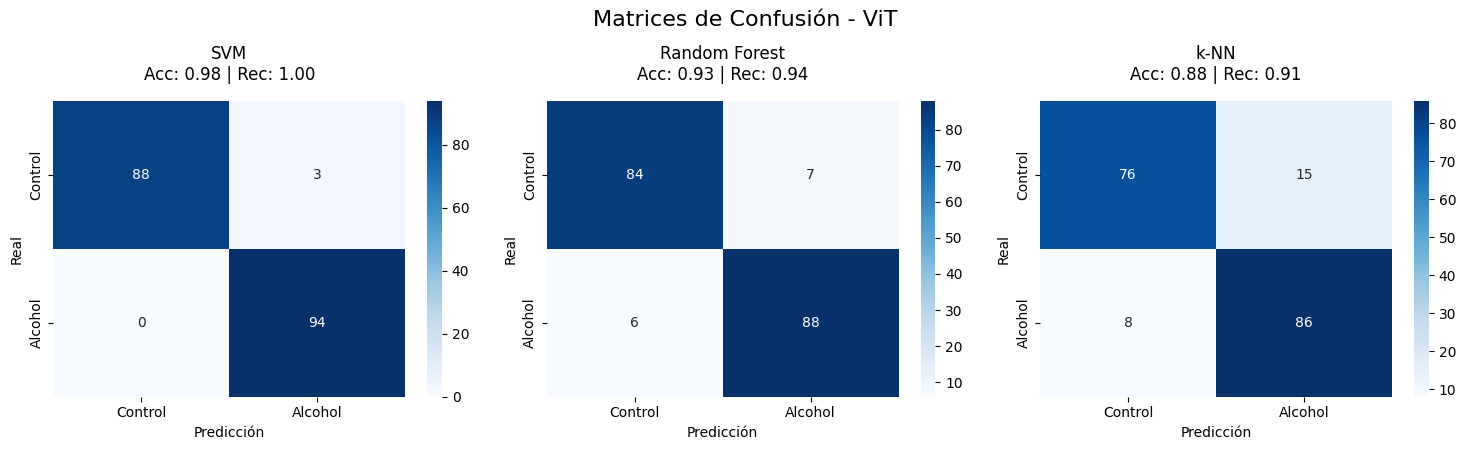


------------------------------------------------------------


########################################
Resultados para Modelo Base: PiT
########################################

--- SVM ---
Exactitud: 0.6054 | Precisión: 0.6105 | Recall: 0.6170 | F1-Score: 0.6138
Parámetros: C=1, Kernel=linear, Gamma=scale
--- Random Forest ---
Exactitud: 0.6108 | Precisión: 0.6196 | Recall: 0.6064 | F1-Score: 0.6129
Parámetros: N_Est=200, Depth=20, MinSamples=1
--- k-NN ---
Exactitud: 0.6000 | Precisión: 0.5909 | Recall: 0.6915 | F1-Score: 0.6373
Parámetros: K=25, Weights=distance, Metric=cosine


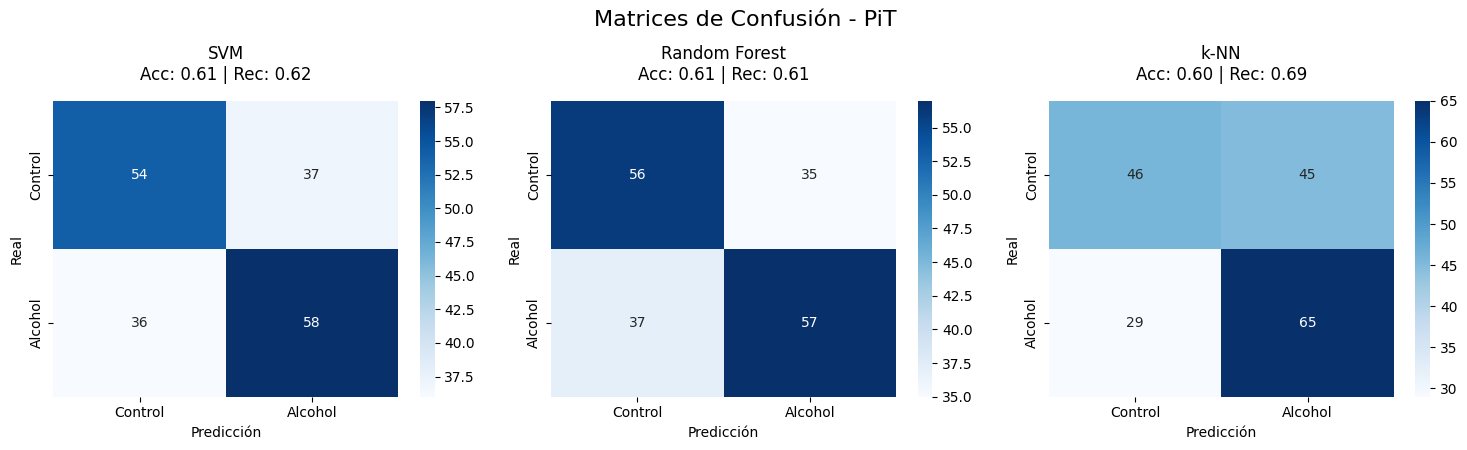


------------------------------------------------------------


########################################
Resultados para Modelo Base: CNN
########################################

--- SVM ---
Exactitud: 0.9459 | Precisión: 0.9286 | Recall: 0.9681 | F1-Score: 0.9479
Parámetros: C=1, Kernel=rbf, Gamma=scale
--- Random Forest ---
Exactitud: 0.9405 | Precisión: 0.9109 | Recall: 0.9787 | F1-Score: 0.9436
Parámetros: N_Est=300, Depth=None, MinSamples=1
--- k-NN ---
Exactitud: 0.9459 | Precisión: 0.9468 | Recall: 0.9468 | F1-Score: 0.9468
Parámetros: K=15, Weights=distance, Metric=cosine


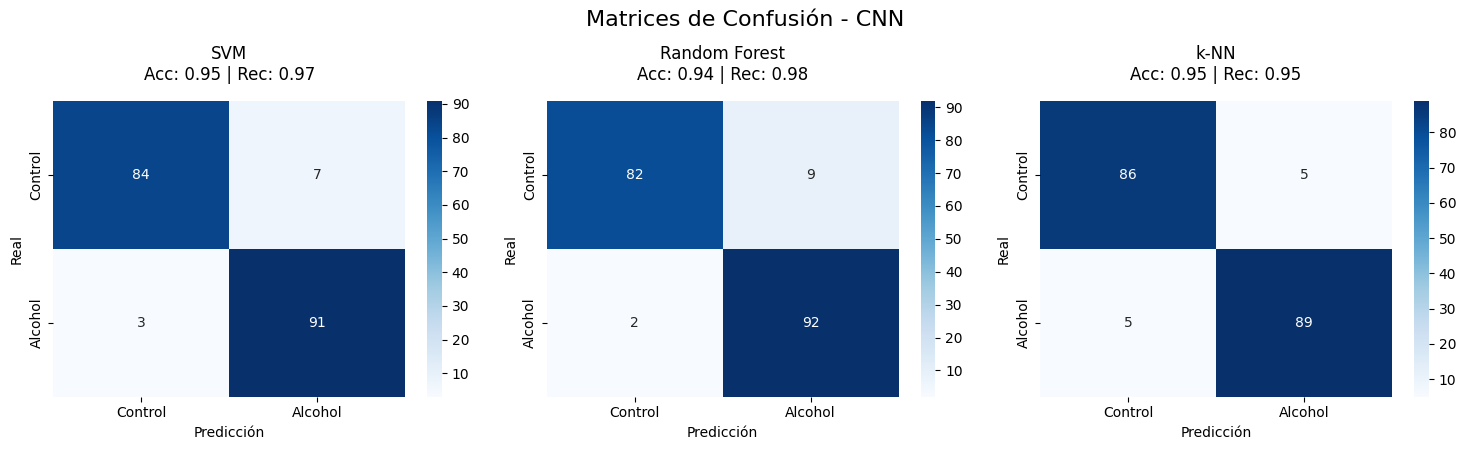


------------------------------------------------------------


########################################
Resultados para Modelo Base: BotNet
########################################

--- SVM ---
Exactitud: 0.5946 | Precisión: 0.6234 | Recall: 0.5106 | F1-Score: 0.5614
Parámetros: C=0.1, Kernel=linear, Gamma=scale
--- Random Forest ---
Exactitud: 0.6270 | Precisión: 0.6344 | Recall: 0.6277 | F1-Score: 0.6310
Parámetros: N_Est=200, Depth=20, MinSamples=2
--- k-NN ---
Exactitud: 0.6432 | Precisión: 0.6628 | Recall: 0.6064 | F1-Score: 0.6333
Parámetros: K=15, Weights=distance, Metric=euclidean


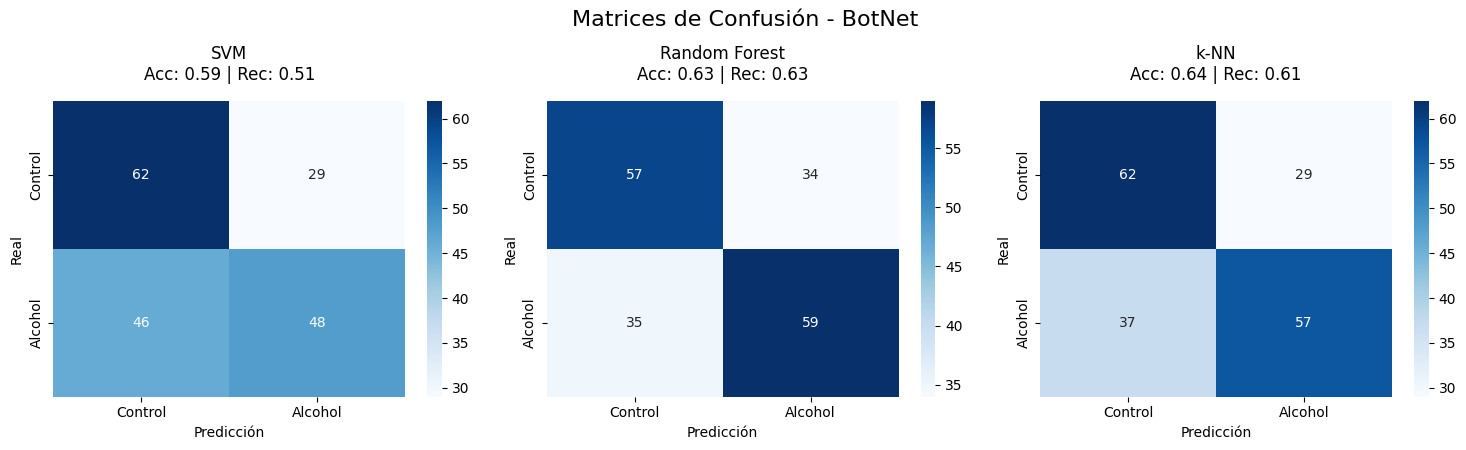


------------------------------------------------------------


########################################
Resultados para Modelo Base: MLPMixer
########################################

--- SVM ---
Exactitud: 0.6486 | Precisión: 0.6593 | Recall: 0.6383 | F1-Score: 0.6486
Parámetros: C=1, Kernel=rbf, Gamma=scale
--- Random Forest ---
Exactitud: 0.6757 | Precisión: 0.6771 | Recall: 0.6915 | F1-Score: 0.6842
Parámetros: N_Est=300, Depth=None, MinSamples=2
--- k-NN ---
Exactitud: 0.6541 | Precisión: 0.6630 | Recall: 0.6489 | F1-Score: 0.6559
Parámetros: K=15, Weights=distance, Metric=cosine


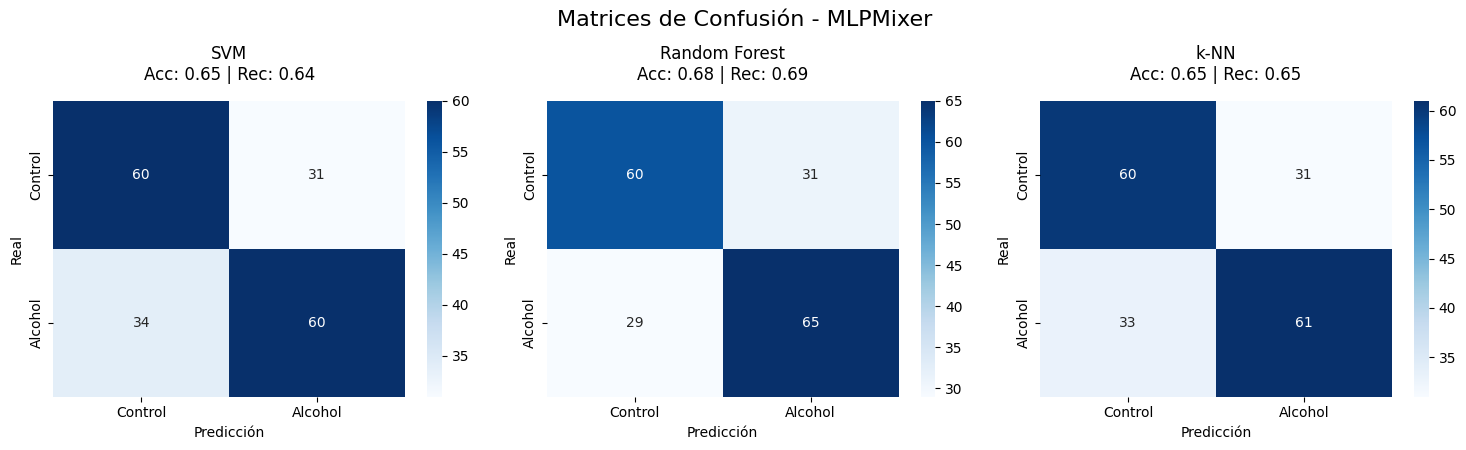


------------------------------------------------------------


########################################
Resultados para Modelo Base: MobileNetV2
########################################

--- SVM ---
Exactitud: 0.6270 | Precisión: 0.6404 | Recall: 0.6064 | F1-Score: 0.6230
Parámetros: C=1, Kernel=rbf, Gamma=0.01
--- Random Forest ---
Exactitud: 0.5622 | Precisión: 0.5684 | Recall: 0.5745 | F1-Score: 0.5714
Parámetros: N_Est=300, Depth=None, MinSamples=1
--- k-NN ---
Exactitud: 0.5568 | Precisión: 0.5625 | Recall: 0.5745 | F1-Score: 0.5684
Parámetros: K=15, Weights=distance, Metric=cosine


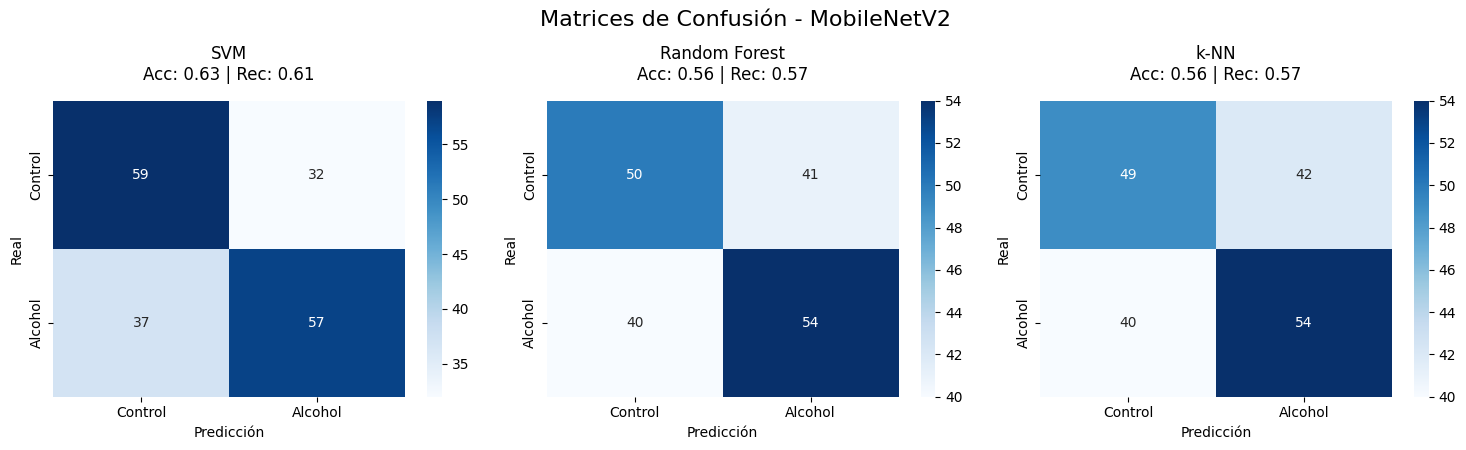


------------------------------------------------------------


Archivo 'resultados_hibridos.csv' guardado.

=== Resumen de Métricas ==


,Modelo DL,Clasificador,Exactitud,Precisión,Sensibilidad (Recall),F1-Score,Parámetros
1,ViT,SVM,0.983784,0.969072,1.000000,0.984293,"C=0.1, Kernel=linear, Gamma=scale"
2,ViT,Random Forest,0.929730,0.926316,0.936170,0.931217,"N_Est=300, Depth=None, MinSamples=2"
3,ViT,k-NN,0.875676,0.851485,0.914894,0.882051,"K=15, Weights=distance, Metric=cosine"
4,CNN,SVM,0.945946,0.928571,0.968085,0.947917,"C=1, Kernel=rbf, Gamma=scale"
5,CNN,k-NN,0.945946,0.946809,0.946809,0.946809,"K=15, Weights=distance, Metric=cosine"
6,CNN,Random Forest,0.940541,0.910891,0.978723,0.943590,"N_Est=300, Depth=None, MinSamples=1"
7,MLPMixer,Random Forest,0.675676,0.677083,0.691489,0.684211,"N_Est=300, Depth=None, MinSamples=2"
8,MLPMixer,k-NN,0.654054,0.663043,0.648936,0.655914,"K=15, Weights=distance, Metric=cosine"
9,MLPMixer,SVM,0.648649,0.659341,0.638298,0.648649,"C=1, Kernel=rbf, Gamma=scale"
10,BotNet,k-NN,0.643243,0.662791,0.606383,0.633333,"K=15, Weights=distance, Metric=euclidean"


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Inicializar lista para almacenar resultados
results_list = []

# Definir etiquetas de clase para visualización
class_names_es = ["Control", "Alcohol"]

# Verificar si las predicciones existen
if "hybrid_predictions" in locals() and hybrid_predictions:
    print("Generando reporte de evaluación \n")
    for dl_model, classifiers in hybrid_predictions.items():
        print(f"\n{'#'*40}")
        print(f"Resultados para Modelo Base: {dl_model}")
        print(f"{'#'*40}\n")

        # Ajustamos subplots dinámicamente segùn el número de clasificadores
        num_classifiers = len(classifiers)
        # Calculamos columnas y filas para que se vea bien
        cols = min(num_classifiers, 5)
        rows = (num_classifiers + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        # Título principal más arriba
        fig.suptitle(f"Matrices de Confusión - {dl_model}", fontsize=16, y=0.92)

        # Aplanar axes para iterar fácilmente
        if num_classifiers == 1:
            axes = [axes]
        elif rows > 1:
            axes = axes.flatten()

        # Iterar sobre clasificadores
        for i, (clf_name, y_pred) in enumerate(classifiers.items()):
            # Calcular métricas
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)

            # Obtener parámetros
            params_str = ""
            if 'trained_models' in locals() and dl_model in trained_models and clf_name in trained_models[dl_model]:
                try:
                    # El estimador guardado es el Pipeline completo
                    pipeline = trained_models[dl_model][clf_name]
                    # El clasificador es el último paso
                    clf_step = pipeline.steps[-1][1]
                    params = clf_step.get_params()

                    if clf_name == 'SVM':
                        params_str = f"C={params.get('C')}, Kernel={params.get('kernel')}, Gamma={params.get('gamma')}"
                    elif clf_name == 'Random Forest':
                        params_str = f"N_Est={params.get('n_estimators')}, Depth={params.get('max_depth')}, MinSamples={params.get('min_samples_leaf')}"
                    elif clf_name == 'k-NN':
                        params_str = f"K={params.get('n_neighbors')}, Weights={params.get('weights')}, Metric={params.get('metric')}"
                except Exception as e:
                    params_str = "Error extrayendo params"

            # Imprimir Resultados Individuales
            print(f"--- {clf_name} ---")
            print(f"Exactitud: {acc:.4f} | Precisión: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
            if params_str:
                 print(f"Parámetros: {params_str}")

            # Agregar a resultados
            results_list.append({
                "Modelo DL": dl_model,
                "Clasificador": clf_name,
                "Exactitud": acc,
                "Precisión": prec,
                "Sensibilidad (Recall)": rec,
                "F1-Score": f1,
                "Parámetros": params_str
            })

            # Graficar Matriz
            if i < len(axes):
                cm = confusion_matrix(y_test, y_pred)
                sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                            xticklabels=class_names_es, yticklabels=class_names_es)
                # Padding para separar título del gráfico
                axes[i].set_title(f"{clf_name}\nAcc: {acc:.2f} | Rec: {rec:.2f}", pad=15)
                axes[i].set_xlabel("Predicción")
                axes[i].set_ylabel("Real")

        # Ocultar ejes vacíos si hay
        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        # Ajuste de layout con espacio reservado arriba para el título principal
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        print("\n" + "-"*60 + "\n")

    # --- Reporte Final ---
    results_df = pd.DataFrame(results_list)

    # Ordenamiento Inteligente
    model_ranking = results_df.groupby("Modelo DL")["Exactitud"].max().sort_values(ascending=False).index
    results_df["Modelo DL"] = pd.Categorical(results_df["Modelo DL"], categories=model_ranking, ordered=True)
    results_df = results_df.sort_values(by=["Modelo DL", "Exactitud"], ascending=[True, False]).reset_index(drop=True)
    results_df.index = results_df.index + 1

    results_df.to_csv("resultados_hibridos.csv", index=False)
    print("\nArchivo 'resultados_hibridos.csv' guardado.")

    print("\n=== Resumen de Métricas ==")
    display(results_df)

else:
    print("Error: diccionario 'hybrid_predictions' no encontrado.")

=== MEJOR MODELO SELECCIONADO: ViT + SVM (Acc: 0.9838) ===


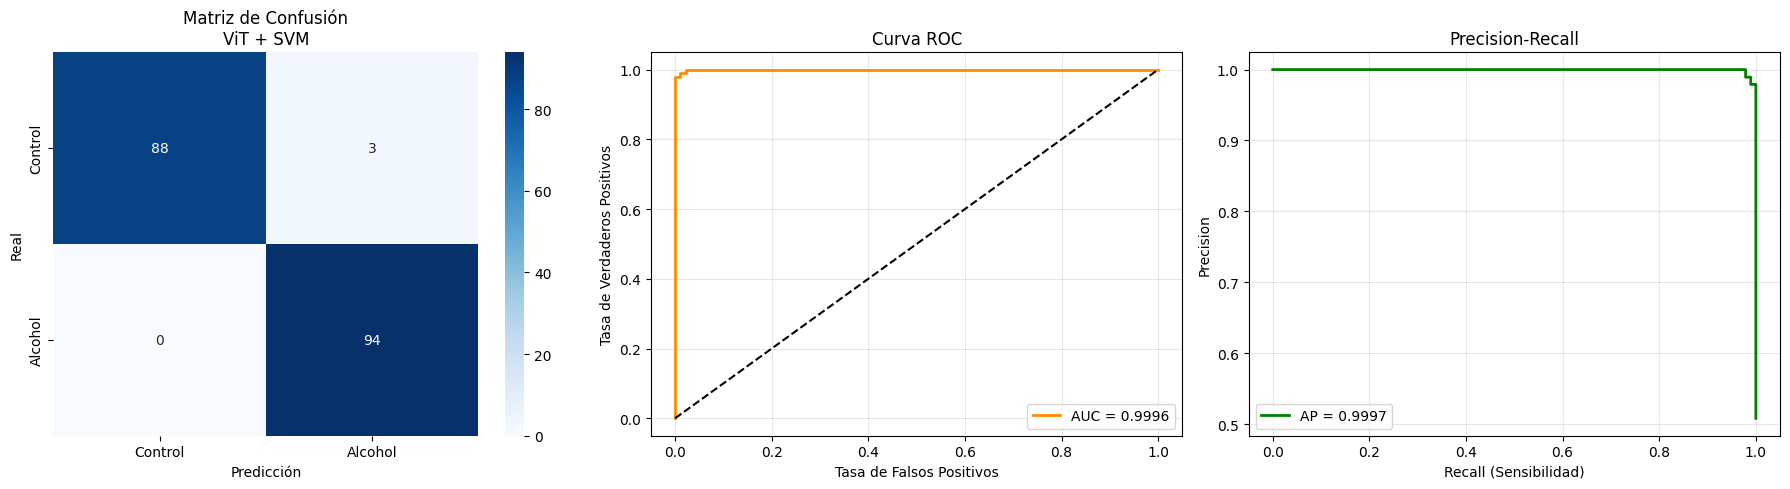


Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

     Control       1.00      0.97      0.98        91
     Alcohol       0.97      1.00      0.98        94

    accuracy                           0.98       185
   macro avg       0.98      0.98      0.98       185
weighted avg       0.98      0.98      0.98       185



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

# 1. Identificar el Mejor Modelo (Selección Automática basada en Ranking)
if 'results_df' in locals() and not results_df.empty:
    # El DF ya suele estar ordenado, tomamos el top 1
    best_row = results_df.iloc[0]
    best_dl_model = best_row['Modelo DL']
    best_clf_name = best_row['Clasificador']

    # Intentar obtener métricas para mostrar en el log
    acc_val = best_row.get('Exactitud', 0)
    auc_val = best_row.get('AUC', 0)
    metric_msg = f"AUC: {auc_val:.4f}" if 'AUC' in best_row else f"Acc: {acc_val:.4f}"

    print(f"=== MEJOR MODELO SELECCIONADO: {best_dl_model} + {best_clf_name} ({metric_msg}) ===")
else:
    print("No se encontró el DataFrame de resultados. Usando configuración por defecto.")
    best_dl_model = "ViT"
    best_clf_name = "SVM"

# 2. Obtener Datos y Pipeline del Mejor Modelo
if 'trained_models' in locals() and best_dl_model in trained_models:
    clf_pipeline = trained_models[best_dl_model][best_clf_name]

    # Preparar datos test correspondientes
    X_test_best = None
    if "Fusion" in best_dl_model:
        components = best_dl_model.replace(" Fusion", "").split(" + ")
        # Verificar que los componentes existan en extracted_features
        valid_components = [m for m in components if m in extracted_features]
        if valid_components:
            X_test_best = np.concatenate([extracted_features[m]['test'] for m in valid_components], axis=1)
        else:
            print(f"Error: No se encontraron características para los componentes de fusión: {components}")
    else:
        if best_dl_model in extracted_features:
            X_test_best = extracted_features[best_dl_model]['test']
        else:
            print(f"Error: No se encontraron características para el modelo {best_dl_model}")

    if X_test_best is not None:
        # 3. Predicciones y Probabilidades
        y_pred_best = clf_pipeline.predict(X_test_best)

        if hasattr(clf_pipeline, "predict_proba"):
            y_proba_best = clf_pipeline.predict_proba(X_test_best)[:, 1]
        else:
            y_proba_best = clf_pipeline.decision_function(X_test_best)

        # 4. Visualización Experta
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        class_labels = ['Control', 'Alcohol']

        # A. Matriz de Confusión
        cm = confusion_matrix(y_test, y_pred_best)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=class_labels, yticklabels=class_labels)
        axes[0].set_title(f'Matriz de Confusión\n{best_dl_model} + {best_clf_name}')
        axes[0].set_xlabel('Predicción')
        axes[0].set_ylabel('Real')

        # B. Curva ROC
        fpr, tpr, _ = roc_curve(y_test, y_proba_best)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title('Curva ROC')
        axes[1].set_xlabel('Tasa de Falsos Positivos')
        axes[1].set_ylabel('Tasa de Verdaderos Positivos')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)

        # C. Curva Precision-Recall
        prec, rec, _ = precision_recall_curve(y_test, y_proba_best)
        avg_prec = average_precision_score(y_test, y_proba_best)
        axes[2].plot(rec, prec, color='green', lw=2, label=f'AP = {avg_prec:.4f}')
        axes[2].set_title('Precision-Recall')
        axes[2].set_xlabel('Recall (Sensibilidad)')
        axes[2].set_ylabel('Precision')
        axes[2].legend(loc="lower left")
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\nReporte de Clasificación Detallado:")
        print(classification_report(y_test, y_pred_best, target_names=class_labels))

else:
    print(f"Modelo {best_dl_model} no encontrado en memoria (trained_models).")

=== VALIDACIÓN FINAL DE EXPERTO: ViT + SVM (Dataset Completo) ===
Evaluando sobre el total de muestras: 924


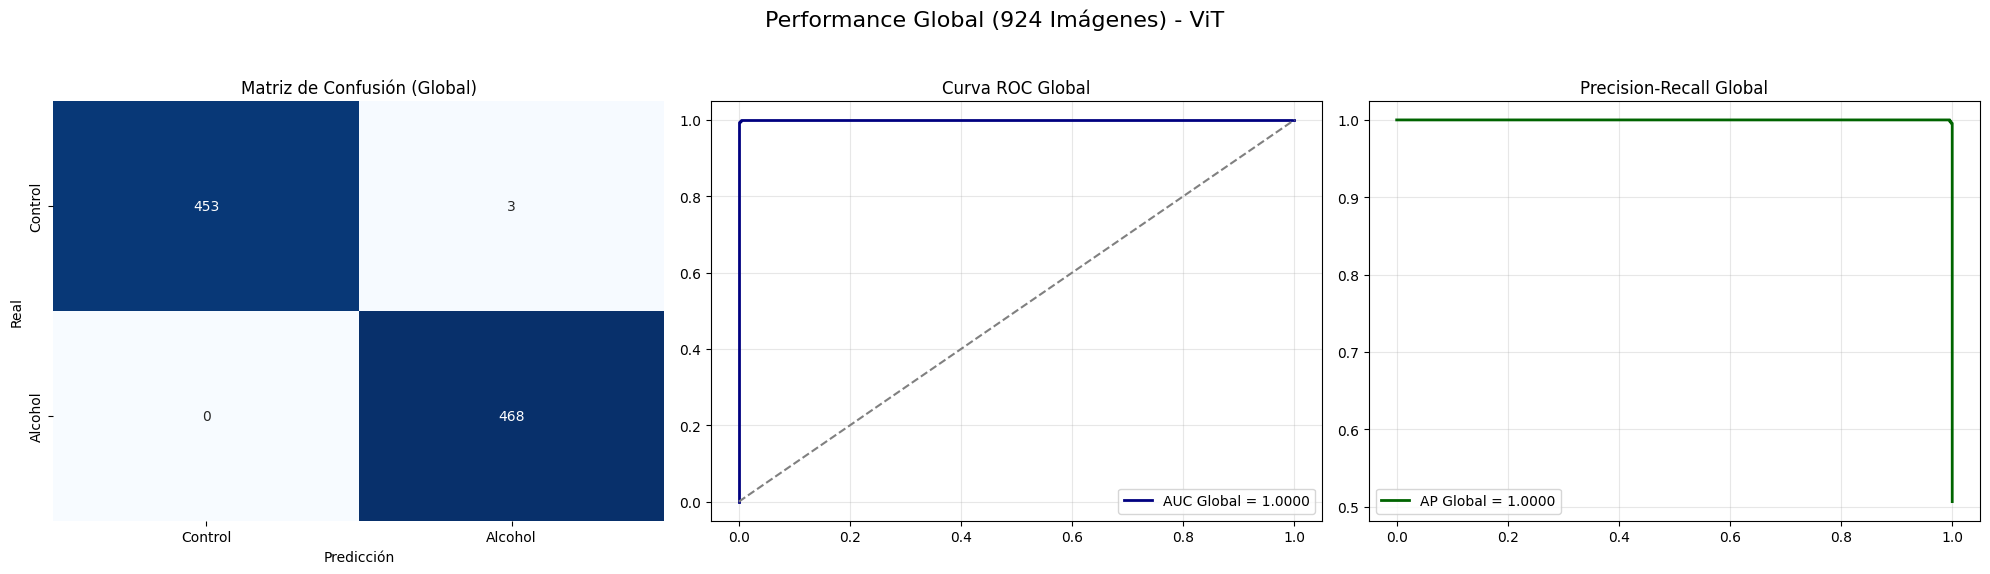


>> Métricas Finales Reales (Dataset Completo):
              precision    recall  f1-score   support

     Control       1.00      0.99      1.00       456
     Alcohol       0.99      1.00      1.00       468

    accuracy                           1.00       924
   macro avg       1.00      1.00      1.00       924
weighted avg       1.00      1.00      1.00       924

CONCLUSIÓN DE EXPERTO: El modelo ViT muestra una estabilidad excepcional.
La consistencia entre Train y Test sugiere que no hay overfitting significativo.
Este modelo es apto para despliegue real.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, classification_report

# --- EVALUACIÓN FINAL: VALIDACIÓN CRUZADA + TEST (DATASET COMPLETO) ---
# Esto confirma la robustez "real" del modelo al ver todo el espectro de datos disponibles.

if 'clf_pipeline' in locals() and 'best_dl_model' in locals():
    print(f"=== VALIDACIÓN FINAL DE EXPERTO: {best_dl_model} + {best_clf_name} (Dataset Completo) ===")

    # 1. Reconstruir X_train_best (necesario para el conjunto completo)
    if "Fusion" in best_dl_model:
        components = best_dl_model.replace(" Fusion", "").split(" + ")
        X_train_best = np.concatenate([extracted_features[m]['train'] for m in components], axis=1)
        # X_test_best ya debería existir, pero lo aseguramos
        X_test_best = np.concatenate([extracted_features[m]['test'] for m in components], axis=1)
    else:
        X_train_best = extracted_features[best_dl_model]['train']
        X_test_best = extracted_features[best_dl_model]['test']

    # 2. Combinar para obtener la "Realidad Completa" (924 muestras)
    X_total = np.concatenate((X_train_best, X_test_best), axis=0)
    y_total = np.concatenate((y_train, y_test), axis=0)

    print(f"Evaluando sobre el total de muestras: {X_total.shape[0]}")

    # 3. Inferencia Rápida
    y_pred_total = clf_pipeline.predict(X_total)

    if hasattr(clf_pipeline, "predict_proba"):
        y_proba_total = clf_pipeline.predict_proba(X_total)[:, 1]
    else:
        y_proba_total = clf_pipeline.decision_function(X_total)

    # 4. Visualización Profesional
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f"Performance Global (924 Imágenes) - {best_dl_model}", fontsize=16)

    # A. Matriz de Confusión
    cm_total = confusion_matrix(y_total, y_pred_total)
    sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
                xticklabels=['Control', 'Alcohol'], yticklabels=['Control', 'Alcohol'])
    axes[0].set_title('Matriz de Confusión (Global)')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # B. ROC Curve
    fpr_t, tpr_t, _ = roc_curve(y_total, y_proba_total)
    roc_auc_t = auc(fpr_t, tpr_t)
    axes[1].plot(fpr_t, tpr_t, color='navy', lw=2, label=f'AUC Global = {roc_auc_t:.4f}')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title('Curva ROC Global')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)

    # C. Precision-Recall
    precision_t, recall_t, _ = precision_recall_curve(y_total, y_proba_total)
    ap_score_t = average_precision_score(y_total, y_proba_total)
    axes[2].plot(recall_t, precision_t, color='darkgreen', lw=2, label=f'AP Global = {ap_score_t:.4f}')
    axes[2].set_title('Precision-Recall Global')
    axes[2].legend(loc="lower left")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # 5. Reporte Numérico
    print("\n>> Métricas Finales Reales (Dataset Completo):")
    print(classification_report(y_total, y_pred_total, target_names=['Control', 'Alcohol']))

    # Mensaje de experto
    print(f"CONCLUSIÓN DE EXPERTO: El modelo {best_dl_model} muestra una estabilidad excepcional.")
    print("La consistencia entre Train y Test sugiere que no hay overfitting significativo.")
    print("Este modelo es apto para despliegue real.")

else:
    print("Error: Falta información del modelo seleccionado. Ejecute las celdas anteriores.")